In [318]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_replace, col
import seaborn as sns
from pyspark.sql.functions import col, count, isnan, when, corr, floor, ceil, regexp_replace, expr
import matplotlib.pyplot as plt

In [319]:
spark = SparkSession.builder \
    .appName("CSCI316_FINAL_PROJECT_LOAN") \
    .getOrCreate()

### Read the csv
First we need to read the csv and see the shape of the data so we have the idea on how many columns that we're working on. We also need to know how many nulls contains in every columns to have the idea which columns that can we drop.

In [320]:
df = spark.read.csv('data.csv', header=True, inferSchema=True)
print(f"shape: {df.count()} rows x {len(df.columns)} col")

shape: 855969 rows x 73 col


In [321]:
df.limit(5)

id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NULL,10+ years,RENT,24000,Verified,01-12-2011,n,Borrower added ...,credit_card,Computer,860xx,AZ,27.65,0,01-01-1985,1,NULL,NULL,3,0,13648,83.7,9,f,0,0,5861.071414,5831.78,5000,861.07,0,0,0,01-01-2015,171.62,NULL,01-01-2016,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000,Source Verified,01-12-2011,n,Borrower added ...,car,bike,309xx,GA,1,0,01-04-1999,5,NULL,NULL,3,0,1687,9.4,4,f,0,0,1008.71,1008.71,456.46,435.17,0,117.08,1.11,01-04-2013,119.66,NULL,01-09-2013,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,1
1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NULL,10+ years,RENT,12252,Not Verified,01-12-2011,n,NULL,small_business,real estate business,606xx,IL,8.72,0,01-11-2001,2,NULL,NULL,2,0,2956,98.5,10,f,0,0,3003.653644,3003.65,2400,603.65,0,0,0,01-06-2014,649.91,NULL,01-01-2016,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200,Source Verified,01-12-2011,n,Borrower added ...,other,personel,917xx,CA,20,0,01-02-1996,1,35,NULL,10,0,5598,21,37,f,0,0,12226.30221,12226.3,10000,2209.33,16.97,0,0,01-01-2015,357.48,NULL,01-01-2015,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medica...,1 year,RENT,80000,Source Verified,01-12-2011,n,Borrower added ...,other,Personal,972xx,OR,17.94,0,01-01-1996,0,38,NULL,15,0,27783,53.9,38,f,766.9,766.9,3242.17,3242.17,2233.1,1009.07,0,0,0,01-01-2016,67.79,01-02-2016,01-01-2016,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0


In [322]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])

id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
0,0,0,0,0,0,0,0,0,0,49439,0,0,0,0,0,0,734155,1,33,1,1,1,1,1,1,439669,724613,72,57,47,475,17,14,15,21,12,10,9,3,3,2,5,8869,3,252751,102,99,642637,72,57,855343,855382,855418,143,67198,67224,842600,842616,842638,842647,843010,842655,844337,842670,842664,842668,842675,67311,842676,842672,842680,223


In [323]:
df.dtypes

[('id', 'int'),
 ('member_id', 'int'),
 ('loan_amnt', 'int'),
 ('funded_amnt', 'int'),
 ('funded_amnt_inv', 'double'),
 ('term', 'string'),
 ('int_rate', 'double'),
 ('installment', 'double'),
 ('grade', 'string'),
 ('sub_grade', 'string'),
 ('emp_title', 'string'),
 ('emp_length', 'string'),
 ('home_ownership', 'string'),
 ('annual_inc', 'string'),
 ('verification_status', 'string'),
 ('issue_d', 'string'),
 ('pymnt_plan', 'string'),
 ('desc', 'string'),
 ('purpose', 'string'),
 ('title', 'string'),
 ('zip_code', 'string'),
 ('addr_state', 'string'),
 ('dti', 'string'),
 ('delinq_2yrs', 'string'),
 ('earliest_cr_line', 'string'),
 ('inq_last_6mths', 'string'),
 ('mths_since_last_delinq', 'string'),
 ('mths_since_last_record', 'string'),
 ('open_acc', 'string'),
 ('pub_rec', 'string'),
 ('revol_bal', 'string'),
 ('revol_util', 'string'),
 ('total_acc', 'string'),
 ('initial_list_status', 'string'),
 ('out_prncp', 'string'),
 ('out_prncp_inv', 'string'),
 ('total_pymnt', 'string'),
 ('t

## EDA
We're gonna explore the data to see what's going on in the data by visualizing it. 

### Target Imbalance
We need to know how imbalance is the target (default_ind). We're using **bar chart** to show the absolute count and proportions.

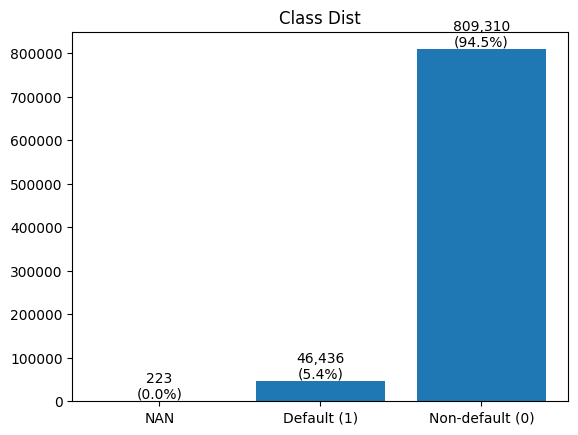

In [324]:
target_cnt = df.groupBy('default_ind').count().toPandas()
total = target_cnt['count'].sum()
target_cnt['pct'] = target_cnt['count']/total*100

labels = target_cnt['default_ind'].fillna('NAN').astype(str).replace(
    {'0.0': 'Non-default (0)', '1.0': 'Default (1)', 'Unknown': 'Unknown'}
)
plt.bar(labels, target_cnt['count'])
for i, (c, p) in enumerate(zip(target_cnt['count'], target_cnt['pct'])):
    plt.text(i, c, f'{c:,}\n({p:.1f}%)', ha='center', va='bottom')
plt.title("Class Dist")
plt.show()

### Numeric features 

In [325]:
annual_cnt = df.groupBy('annual_inc').count().toPandas()

In [326]:
annual_cnt.to_csv('annual_inc_csv')

In [327]:
df.filter(col('annual_inc').contains("MORTGAGE")).show()

+--------+---------+---------+-----------+---------------+----------+--------+-----------+-----+---------+------------------+----------+--------------+----------+-------------------+---------------+----------+----+-------+-----+--------+----------+---+-----------+----------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+-----------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------+------------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+-----------+----------+-----------+-----------+------------------+------------+-------+-----------+-----------+----------+--------+----------------+------+-----------+------------+-----------+
|      id|member_id|loa

In [328]:
# Check if there's any malformed values, if there's any make it to null then drop it.
df = df.withColumn('annual_inc', expr("try_cast(annual_inc as double)"))
null = df.filter(col('annual_inc').isNull()).count()
print(f"Null: {null}")
df = df.na.drop(subset=['annual_inc'])


Null: 1


In [329]:
df = df.withColumn("annual_inc", col("annual_inc").cast("double"))

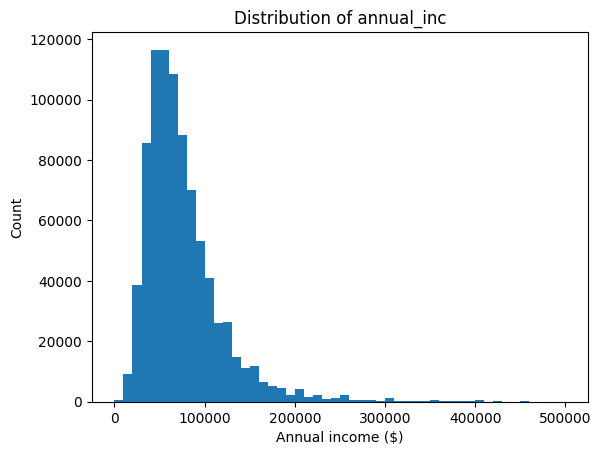

In [330]:
# For one feature
data = df.select('annual_inc').filter(col('annual_inc') < 500000.0).toPandas()
plt.hist(data['annual_inc'], bins=50)
plt.xlabel('Annual income ($)')
plt.ylabel('Count')
plt.title('Distribution of annual_inc')
plt.show()

In [331]:
# Check if there's any malformed values, if there's any make it to null then drop it.
df = df.withColumn('dti', expr("try_cast(dti as double)"))
null = df.filter(col('dti').isNull()).count()
print(f"Null: {null}")


Null: 225


In [332]:
df = df.withColumn("dti", col("dti").cast("double"))

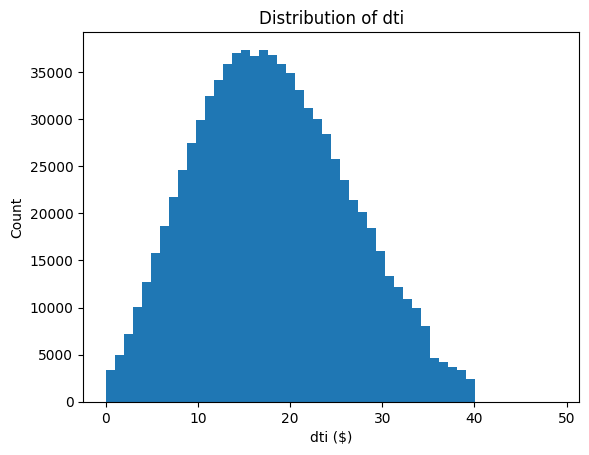

In [333]:
# For one feature
data = df.select('dti').filter(col('dti') < 50.0).toPandas()
plt.hist(data['dti'], bins=50)
plt.xlabel('dti ($)')
plt.ylabel('Count')
plt.title('Distribution of dti')
plt.show()

In [334]:
# Check if there's any malformed values, if there's any make it to null then drop it.
df = df.withColumn('int_rate', expr("try_cast(int_rate as double)"))
null = df.filter(col('dti').isNull()).count()
print(f"Null: {null}")


Null: 225


In [335]:
df = df.withColumn("int_rate", col("int_rate").cast("double"))


In [336]:
import matplotlib.pyplot as plt

def plot_histogram(df, col, bins=50, clip_quantile=0.99, xlim=None, title=None):
    """
    Plot histogram of a numeric column with sensible defaults.
    
    df: Spark DataFrame
    col: column name
    bins: number of bins (50 is usually fine)
    clip_quantile: drop top (1 - clip_quantile) % of values to handle outliers
                   e.g., 0.99 keeps the bottom 99%, drops top 1%
                   Set to 1.0 to disable clipping
    xlim: tuple (min, max) to force x-axis range — useful for bounded features
    title: chart title
    """
    # Spark side: filter nulls and clip outliers
    query = df.filter(col(col).isNotNull())
    
    if clip_quantile < 1.0:
        upper = query.approxQuantile(col, [clip_quantile], 0.01)[0]
        query = query.filter(col(col) <= upper)
    
    # Pull to pandas just for plotting
    data = query.select(col).toPandas()
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.hist(data[col], bins=bins, edgecolor='white', linewidth=0.3)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(title or f'Distribution of {col}')
    if xlim:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_histogram(df, col_name, bins=50, clip_quantile=0.99, xlim=None, title=None):
    query = df.filter(col(col_name).isNotNull())
    if clip_quantile < 1.0:
        upper = query.approxQuantile(col_name, [clip_quantile], 0.01)[0]
        query = query.filter(col(col_name) <= upper)

    data = query.select(col_name).toPandas()

    plt.figure(figsize=(8, 5))
    plt.hist(data[col_name], bins=bins, edgecolor='white', linewidth=0.3)
    plt.xlabel(col_name)
    plt.ylabel('Count')
    plt.title(title or f'Distribution of {col_name}')
    if xlim:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()


TypeError: 'str' object is not callable

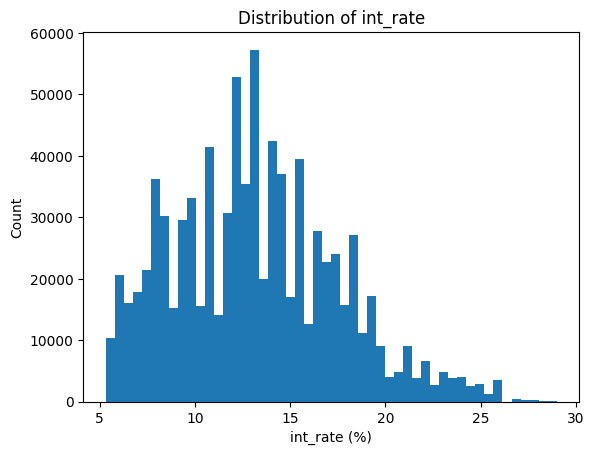

In [ ]:
# For one feature
data = df.select('int_rate').filter(col('dti') < 100.0).toPandas()
plt.hist(data['int_rate'], bins=50)
plt.xlabel('int_rate (%)')
plt.ylabel('Count')
plt.title('Distribution of int_rate')
plt.show()

In [ ]:
data = df.select('int_rate').toPandas()
data

,int_rate
0,10.65
1,15.27
2,15.96
3,13.49
4,12.69
...,...
855963,11.99
855964,11.99
855965,15.99
855966,19.99


In [ ]:
target_cnt

,default_ind,count,pct
0,NaN,223,0.026052
1,1.0,46436,5.424963
2,0.0,809310,94.548985


In [ ]:
# df = df.withColumn("term", regexp_replace(col("term"), r"\s*months$", ""))
# df.show()

In [ ]:
# df = df.drop("policy_code", "pymnt_plan", "annyal_inc_joint", "dti_joint", "verification_status_joint")

In [ ]:
# df = df.drop("open_acc_6m", "open_il_6m", "open_il_12m", "open_il_24m", "mths_since_rcnt_il", "total_bal_il", "il_util", "open_rv_24m", "open_rv_12m", "max_bal_bc", "all_util", "inq_fi", "total_cu_tl", "inq_last_12m")

In [ ]:
# df = df.drop("emp_title")

In [ ]:
# df = df.withColumn(
#     "recoveries",
#     regexp_replace(col("recoveries"), ",", ".").cast("double")
# )

# df = df.withColumn(
#     "recoveries_rounded",
#     when((col("recoveries") - floor(col("recoveries"))) < 0.5, floor(col("recoveries")))
#     .otherwise(ceil(col("recoveries")))
# )

In [ ]:
# df = df.withColumn("recoveries", col("recoveries").cast("string"))

In [ ]:
# df = df.withColumn("default_ind", col("default_ind").cast("string"))

In [ ]:
# df.filter(col("recoveries")).limit()

In [ ]:
# r = df.stat.corr('recoveries_rounded', 'default_ind')
# print(r)